# 1. Recortes e Mesclas com Matrizes (Fatiamento)

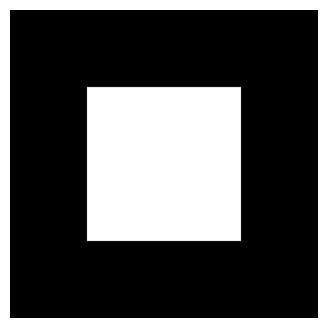

In [33]:
import numpy as np
import matplotlib.pyplot as plt

# 1.a: Criando a Máscara
mascara = np.zeros((200, 200), dtype=np.uint8)
mascara[50:150, 50:150] = 255

plt.figure(figsize=(4,4))
plt.imshow(mascara, cmap='gray', vmin=0, vmax=255)
plt.axis('off')
plt.show()

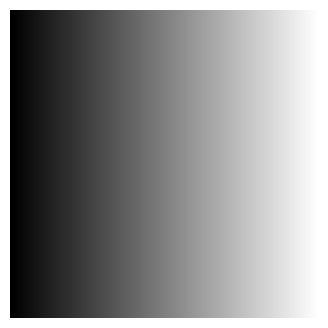

In [34]:
# 1.b: Criando o Degradê
linha_gradiente = np.linspace(0, 255, 200, dtype=np.uint8)
degrade = np.tile(linha_gradiente, (200, 1))

plt.figure(figsize=(4,4))
plt.imshow(degrade, cmap='gray', vmin=0, vmax=255)
plt.axis('off')
plt.show()

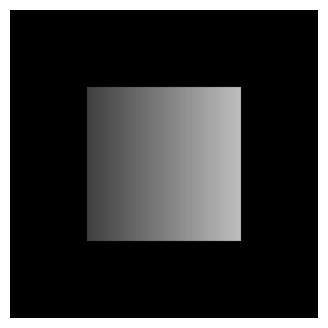

In [35]:
# 1.c: Mesclando as Imagens
resultado_mescla = np.where(mascara == 255, degrade, 0).astype(np.uint8)

plt.figure(figsize=(4,4))
plt.imshow(resultado_mescla, cmap='gray', vmin=0, vmax=255)
plt.axis('off')
plt.show()

# 2. Brincando com Canais de Cor (Espaço RGB)

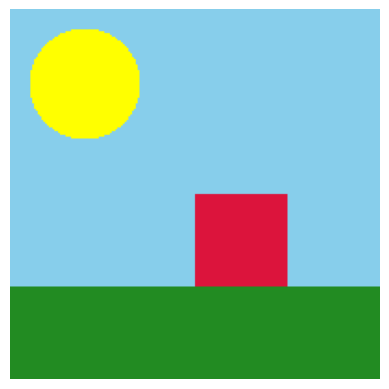

In [36]:
# 2.a: Leitura Original
imagem_path = 'assets/q2_a_original.png'
imagem_original = plt.imread(imagem_path)

# se tem apenas 3 canais RGB caso contrario joga fora o alpha
if len(imagem_original.shape) == 3 and imagem_original.shape[2] == 4:
    imagem_original = imagem_original[:, :, :3]

# mapea de volta a uint8 [0, 255]
if imagem_original.dtype == np.float32 and imagem_original.max() <= 1.0:
    imagem_original = (imagem_original * 255).astype(np.uint8)

plt.imshow(imagem_original)
plt.axis('off')
plt.show()

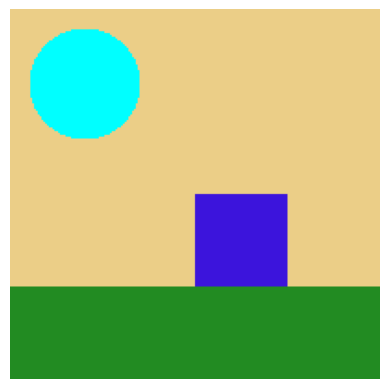

In [37]:
# 2.b: Efeito Inverso (Troca de Canais - Formato BGR)
imagem_copia = np.copy(imagem_original)
imagem_bgr = imagem_copia[..., [2, 1, 0]]

plt.imshow(imagem_bgr)
plt.axis('off')
plt.show()

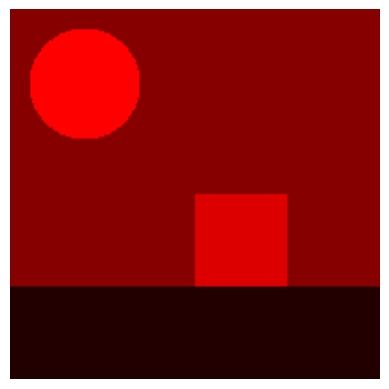

In [38]:
# 2.c: Filtro Vermelho Forte
imagem_copia_red = np.copy(imagem_original)
imagem_copia_red[:, :, 1] = 0 # zero verde
imagem_copia_red[:, :, 2] = 0 # zero azul

plt.imshow(imagem_copia_red)
plt.axis('off')
plt.show()

# 3. Cálculos Estatísticos e Limiarização

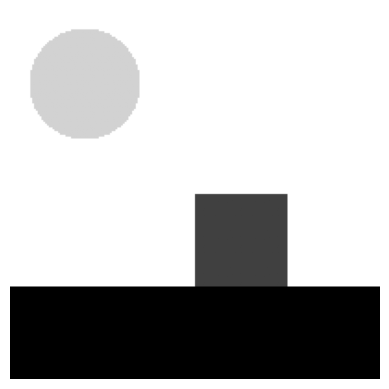

In [39]:
# 3.a: Conversão para Tons de Cinza pela Média
imagem_cinza = np.mean(imagem_original, axis=2).astype(np.uint8)

plt.imshow(imagem_cinza, cmap='gray')
plt.axis('off')
plt.show()

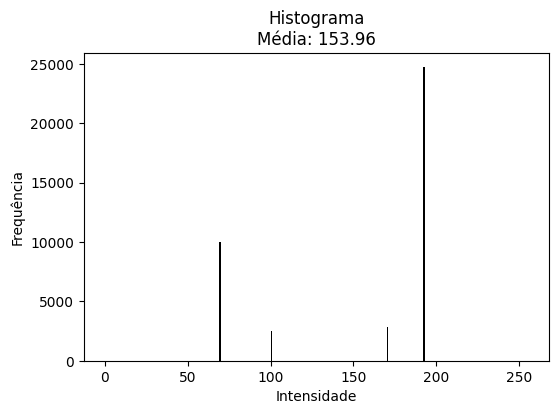

In [40]:
# 3.b: Histograma e a Média Geral
media_geral = np.mean(imagem_cinza)

plt.figure(figsize=(6,4))
plt.hist(imagem_cinza.flatten(), bins=255, range=(0, 255), color='black')
plt.title(f"Histograma\nMédia: {media_geral:.2f}")
plt.xlabel("Intensidade")
plt.ylabel("Frequência")
plt.show()

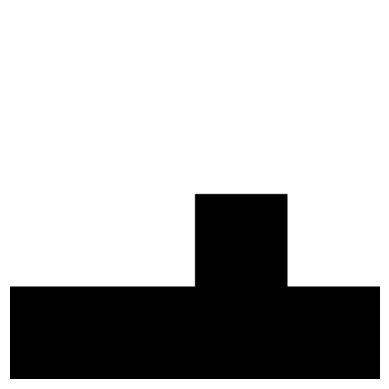

In [41]:
# 3.c: Limiarização Analítica Automática
imagem_limiarizada = np.where(imagem_cinza >= media_geral, 255, 0).astype(np.uint8)

plt.imshow(imagem_limiarizada, cmap='gray', vmin=0, vmax=255)
plt.axis('off')
plt.show()

# 4. Efeito "Chroma Key" (Isolando a Máscara e Substituindo o Fundo)

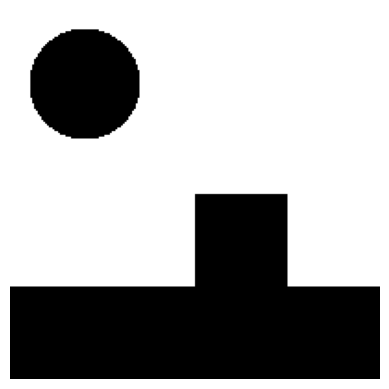

In [42]:
# 4.a: Isolando / Mapeando o Fundo
# Mascara logica booleana ident a cor de fundo
ceus_mascara_logica = (imagem_original[:,:,0] == 135) & \
                      (imagem_original[:,:,1] == 206) & \
                      (imagem_original[:,:,2] == 235)
                      
mapa_fundo = (ceus_mascara_logica * 255).astype(np.uint8)

plt.imshow(mapa_fundo, cmap='gray', vmin=0, vmax=255)
plt.axis('off')
plt.show()

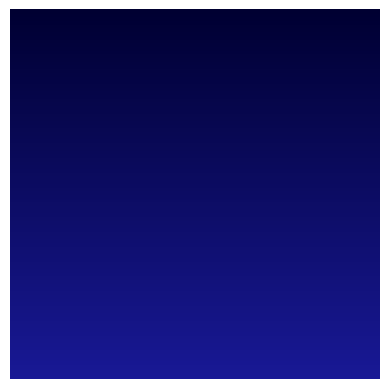

In [43]:
# 4.b: Gerando ou Recebendo um Novo Fundo
imagem_fundo_path = 'assets/q4_b_fundo.png'
novo_fundo = plt.imread(imagem_fundo_path)

if novo_fundo.shape[2] == 4:
    novo_fundo = novo_fundo[:, :, :3]
if novo_fundo.dtype == np.float32 and novo_fundo.max() <= 1.0:
    novo_fundo = (novo_fundo * 255).astype(np.uint8)

plt.imshow(novo_fundo)
plt.axis('off')
plt.show()

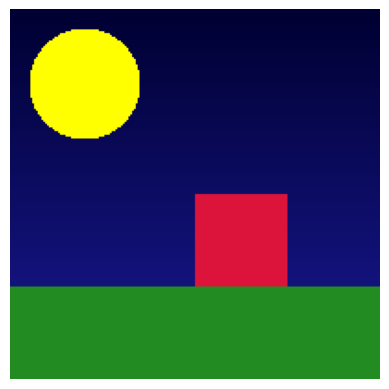

In [44]:
# 4.c: Sobreposição e Mescla

imagem_chroma_key = np.copy(imagem_original)

imagem_chroma_key[ceus_mascara_logica] = novo_fundo[ceus_mascara_logica]

plt.imshow(imagem_chroma_key)
plt.axis('off')
plt.show()